# Introduction to Machine Learning project: Breast cancer classification
## Kovács Levente, Tasnádi Bálint

In our machine learning project, we aim to develop a convulational neural network (CNN) based system that can be used to detect pathologic malformations (in particular, signs of Invasive Ductal Carcinoma) in breast tissue based on hystology slides.

We plan to use the following dataset: https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images

Our plan is to build a classifier by using approximately 80% of our posessed data. Furthermore, we intend to create a confusion matrix, so we can evaluate our model's performance.

In [9]:
from glob import glob #filenames
from os import path

import cv2 #image processing

import matplotlib.pyplot as plt

import pandas as pd #data storage
import numpy as np
import kagglehub
import random

In [6]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-histopathology-images' dataset.
Path to dataset files: /kaggle/input/breast-histopathology-images


## Dataset description

Humongous (3GB) dataset from 162 breast cancer specimens, broken into 277,524 50x50 patches (198,738 negative, 78,786 positive).

In [7]:
data_filenames = glob('/kaggle/input/breast-histopathology-images/IDC_regular_ps50_idx5/**/**/*.png') #finds all .png files in data/ and subdirectories

print(f'Found {len(data_filenames)} files') #total no of files

Found 277524 files


for playing around, let's select 10k positive and 10k negative images. There is a 1:2 class imbalance in the original dataset, we can circumvent it by only working on a small subset for now.

In [10]:
positive_filepaths = [f for f in data_filenames if f.endswith('_class1.png')]
negative_filepaths = [f for f in data_filenames if f.endswith('_class0.png')]

num_samples = 10000

selected_positive_filepaths = random.sample(positive_filepaths, min(num_samples, len(positive_filepaths)))
selected_negative_filepaths = random.sample(negative_filepaths, min(num_samples, len(negative_filepaths)))

print(f'Selected {len(selected_positive_filepaths)} positive images and {len(selected_negative_filepaths)} negative images.')

# Combine and shuffle the selected file paths
selected_filepaths = selected_positive_filepaths + selected_negative_filepaths
random.shuffle(selected_filepaths)

Selected 10000 positive images and 10000 negative images.


In [11]:
def load_and_preprocess_image(filepath, target_size=(50, 50)):
    img = cv2.imread(filepath) #read image at path
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

    #check if 50x50x3
    if img.shape[0] != target_size[0] or img.shape[1] != target_size[1]:
        return None # Exclude images that are not 50x50
    return img


images = []
labels = []

for filepath in selected_filepaths:
    img = load_and_preprocess_image(filepath)
    if img is not None:
        images.append(img)
        # Extract label from filename (class0 or class1)
        label = int(filepath.split('_class')[-1].split('.')[0])
        labels.append(label)

data_20k_images = np.array(images)
data_20k_labels = np.array(labels)

print(f'Shape of loaded images array: {data_20k_images.shape}')
print(f'Shape of loaded labels array: {data_20k_labels.shape}')

Shape of loaded images array: (19864, 50, 50, 3)
Shape of loaded labels array: (19864,)


In [16]:
np.save('data_20k_images.npy', data_20k_images)

## Example images

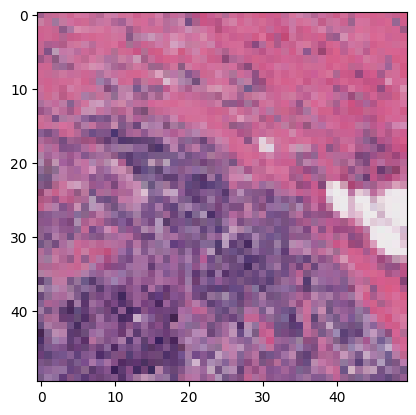

In [12]:
plt.imshow(data_20k_images[0])

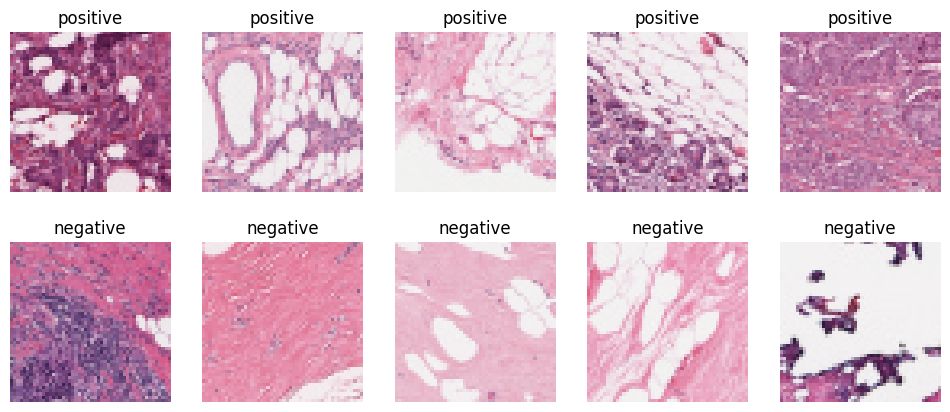

In [15]:
positive_images_display = []
negative_images_display = []

positive_count = 0
negative_count = 0

for i in range(len(data_20k_images)):
    if data_20k_labels[i] == 1 and positive_count < 5: #if positive save to positive
        positive_images_display.append(data_20k_images[i])
        positive_count += 1
    elif data_20k_labels[i] == 0 and negative_count < 5: #if negative save to negative
        negative_images_display.append(data_20k_images[i])
        negative_count += 1

    if positive_count == 5 and negative_count == 5: #break if done
        break

plt.figure(figsize=(12, 5))

#positive
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(positive_images_display[i])
    plt.axis('off')
    plt.title("positive")

#negative
for i in range(5):
    plt.subplot(2, 5, i + 6)
    plt.imshow(negative_images_display[i])
    plt.title("negative")
    plt.axis('off')

## Train, test, validate sets

In [18]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
